# SWIGGY SALES ANALYSIS

### Import Libraries

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datasets
import plotly.express as px
import seaborn as sns

### Importing Data

In [38]:
df = pd.read_excel("C:/Data Analysis/PYTHON/Swiggy Raw Data.xlsx")

In [39]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [40]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


### Metadata

In [41]:
print("No. of rows in the dataset :",df.shape[0])  

No. of rows in the dataset : 197430


In [42]:
print("No. of fiels in the dataset :",df.shape[1])

No. of fiels in the dataset : 10


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  str           
 1   City             197430 non-null  str           
 2   Order Date       197430 non-null  datetime64[us]
 3   Restaurant Name  197430 non-null  str           
 4   Location         197430 non-null  str           
 5   Category         197430 non-null  str           
 6   Dish Name        197430 non-null  str           
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(1), str(6)
memory usage: 30.8 MB


### Datatypes

In [44]:
df.dtypes

State                         str
City                          str
Order Date         datetime64[us]
Restaurant Name               str
Location                      str
Category                      str
Dish Name                     str
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

In [45]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996809,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


### KPI's

#### Total Sales

In [46]:
print("Total Sales (INR):",round(df["Price (INR)"].sum(),2))

Total Sales (INR): 53012505.77


#### Average Rating

In [47]:
print("Average Rating :",round(df["Rating"].mean(),1))

Average Rating : 4.3


### Average Order Value

In [48]:
print("Average Order Value (INR):",round(df["Price (INR)"].mean(),2))

Average Order Value (INR): 268.51


### Ratings Count   

In [49]:
print("Ratings Count:",round(df["Rating Count"].sum()))

Ratings Count: 5591574


### Total Orders

In [50]:
total_orders = len(df)
print("Total number of orders:",total_orders)

Total number of orders: 197430


# Charts

### Monthly Sales Trend

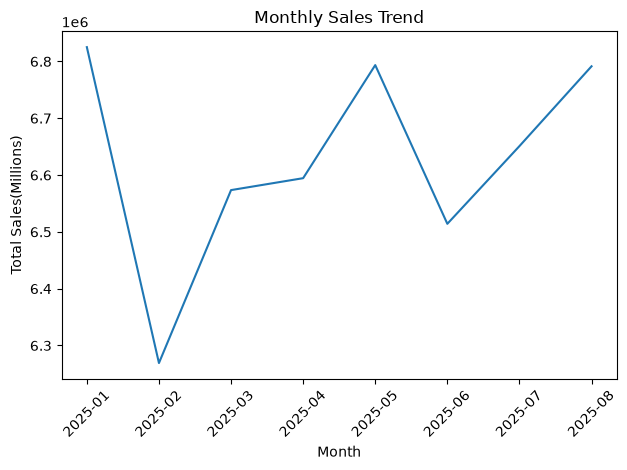

<Figure size 400x300 with 0 Axes>

In [51]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)

monthly_revenue = df.groupby("YearMonth")["Price (INR)"].sum().reset_index()

plt.Figure()
plt.plot(monthly_revenue["YearMonth"],monthly_revenue["Price (INR)"])
plt.xticks(rotation = 45)
plt.xlabel("Month")
plt.ylabel("Total Sales(Millions)")
plt.title("Monthly Sales Trend")
plt.tight_layout()
plt.figure(figsize=(4,3))
plt.show()

### Daily Sales Trend

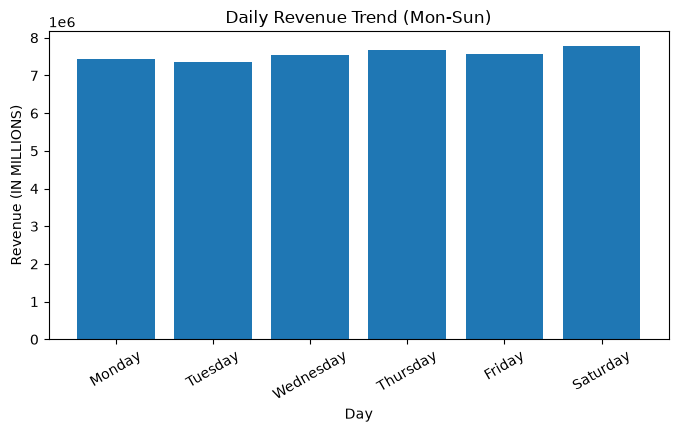

In [52]:
df["DayName"] = pd.to_datetime(df["Order Date"]).dt.day_name()

daily_revenue = (
    df.groupby("DayName")["Price (INR)"]
    .sum()
    .reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday"])
    )

plt.figure(figsize=(8,4))
plt.bar(daily_revenue.index,daily_revenue.values)
plt.title("Daily Revenue Trend (Mon-Sun)")
plt.xlabel("Day")
plt.ylabel("Revenue (IN MILLIONS)")
plt.xticks(rotation = 30)
plt.show()

### Total Sales by Food type(Veg/Non-Veg)

In [53]:
non_veg_keywords = [
    "chicken","egg","fish","mutton","prawn", "biryani", "kabab","kebab","non-veg","non veg"
]

df["Food Category"] = np.where(df["Dish Name"].str.lower().str.contains("|".join(non_veg_keywords),na=False),
    "Non-Veg",
    "Veg"
)

In [54]:
food_revenue = (df.groupby("Food Category")["Price (INR)"]
                .sum()
                .reset_index()
)

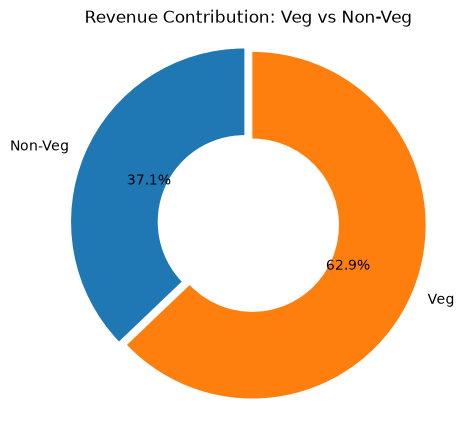

In [61]:
# Revenue by Food Category
food_revenue = df.groupby("Food Category")["Price (INR)"].sum()

# Labels and values
labels = food_revenue.index
sizes = food_revenue.values

# Create donut chart
plt.figure(figsize=(5,5))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05, 0],   # Pull out first slice
    wedgeprops={"width": 0.5}  # Creates donut hole
)

plt.title("Revenue Contribution: Veg vs Non-Veg")
plt.axis("equal")  # Makes it circular

plt.show()


### Total Sales By State

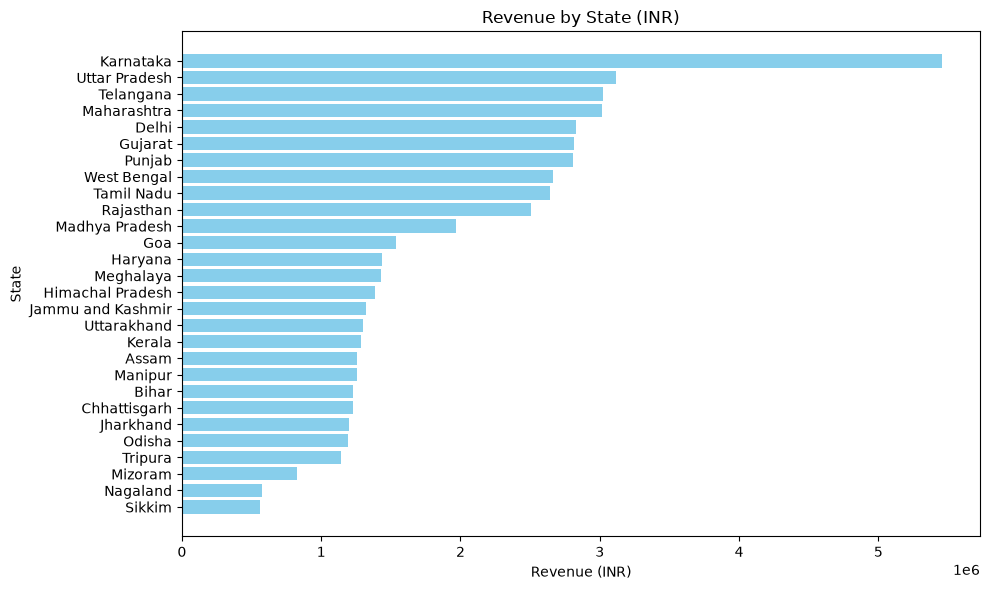

In [70]:
import matplotlib.pyplot as plt

# State-wise Revenue
state_revenue = (
    df.groupby("State", as_index=False)["Price (INR)"]
      .sum()
      .sort_values("Price (INR)", ascending=True)
)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(
    state_revenue["State"],
    state_revenue["Price (INR)"],
    color="skyblue"
)

plt.title("Revenue by State (INR)")
plt.xlabel("Revenue (INR)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

### Quarterly Performance Summary

In [65]:
df["Order_Date"] = pd.to_datetime(df["Order Date"])

df["Quarter"] = df["Order_Date"].dt.to_period("Q").astype(str)

quarterly_summary = (
    df.groupby("Quarter", as_index=False)
      .agg(
          Total_Sales=("Price (INR)", "sum"),
          Avg_Rating=("Rating", "mean"),
          Total_Orders=("Order_Date", "count")
      )
      .sort_values("Quarter")
)

quarterly_summary["Total_Sales"] = quarterly_summary["Total_Sales"].round(0)
quarterly_summary["Avg_Rating"] = quarterly_summary["Avg_Rating"].round(2)

quarterly_summary

,Quarter,Total_Sales,Avg_Rating,Total_Orders
0,2025Q1,19667822.0,4.34,73096
1,2025Q2,19902257.0,4.34,74163
2,2025Q3,13442427.0,4.34,50171


### Top 5 City By Sales

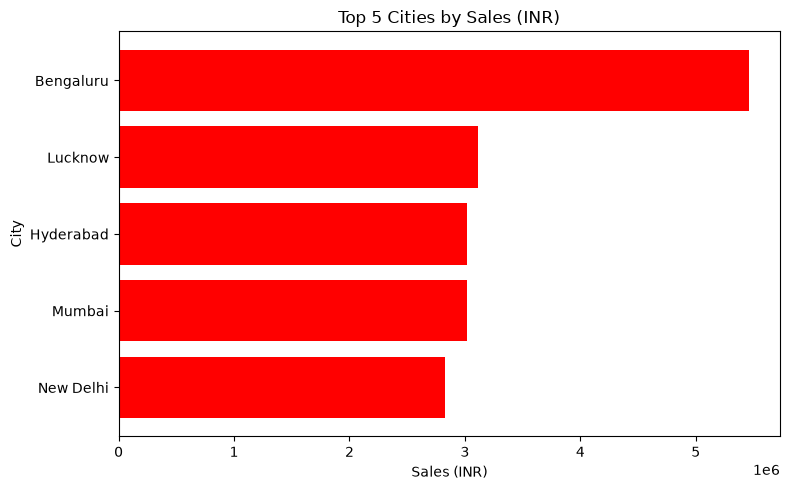

In [69]:
# Top 5 Cities by Revenue
top_5_cities = (
    df.groupby("City")["Price (INR)"]
      .sum()
      .nlargest(5)
      .sort_values()
)

# Plot
plt.figure(figsize=(8,5))
plt.barh(top_5_cities.index, top_5_cities.values, color="red")

plt.title("Top 5 Cities by Sales (INR)")
plt.xlabel("Sales (INR)")
plt.ylabel("City")

plt.tight_layout()
plt.show()